In [3]:
import numpy as np
import lightkurve as lk 
import matplotlib.pyplot as plt 
from astroquery.jplhorizons import Horizons
import pandas as pd
from astropy.time import Time

In [4]:
# From Animation70
def getData(ra:float, dec:float, sectorno:int):
    location = str(ra) + ", " + str(dec)
    search_result = lk.search_tesscut(location, sector=sectorno)
    tpf = search_result.download(cutout_size=20)
    return tpf

In [5]:
# time conversions

def BTJDtoUTC(btjd):
    bjd = btjd + 2457000.0  # BTJD is BJD - 2457000.0
    time_bjd = Time(bjd, format='jd', scale='tdb')
    time_utc = time_bjd.utc.iso
    return time_utc
"""
def cadenceToUTC(total_cadence, btjd_min, btjd_max): #ig in theory you could just do this based on tess cadence
    step_days = (btjd_max - btjd_min) / total_cadence
    step_minutes = step_days * 1440
    return step_minutes
"""
    
print(BTJDtoUTC(3208) + " " + BTJDtoUTC(3234))
#cadenceToUTC(10715, 3208, 3234)

2023-09-20 11:58:50.818 2023-10-16 11:58:50.818


In [6]:
# Get the location of Neptune during a certain time (Neptune Horizons id is 899)

eph_cols = ['targetname', 'datetime_str', 'datetime_jd', 'RA', 'DEC']

start_70 = str(BTJDtoUTC(3208))
stop_70 = str(BTJDtoUTC(3234))
cadence_70 = '10715'

sector_70 = Horizons(id=899, epochs={'start':start_70, 'stop':stop_70, 'step':cadence_70})
ephemeris_70 = sector_70.ephemerides()
df_70 = ephemeris_70.to_pandas()[eph_cols]

#column titles
header_70 = ephemeris_70.colnames

print(df_70)

          targetname              datetime_str   datetime_jd         RA  \
0      Neptune (899)  2023-Sep-20 11:58:50.818  2.460208e+06  356.75201   
1      Neptune (899)  2023-Sep-20 12:02:20.468  2.460208e+06  356.75195   
2      Neptune (899)  2023-Sep-20 12:05:50.118  2.460208e+06  356.75189   
3      Neptune (899)  2023-Sep-20 12:09:19.768  2.460208e+06  356.75183   
4      Neptune (899)  2023-Sep-20 12:12:49.418  2.460208e+06  356.75177   
...              ...                       ...           ...        ...   
10711  Neptune (899)  2023-Oct-16 11:44:52.218  2.460234e+06  356.12316   
10712  Neptune (899)  2023-Oct-16 11:48:21.868  2.460234e+06  356.12310   
10713  Neptune (899)  2023-Oct-16 11:51:51.518  2.460234e+06  356.12305   
10714  Neptune (899)  2023-Oct-16 11:55:21.168  2.460234e+06  356.12300   
10715  Neptune (899)  2023-Oct-16 11:58:50.818  2.460234e+06  356.12294   

           DEC  
0     -2.79780  
1     -2.79783  
2     -2.79786  
3     -2.79788  
4     -2.79791

In [7]:
#Making a circular aperture functions

def circularAperture(dimensions, center, radius):
    """
    Create a boolean array with specified dimensions, setting a circular area to True.
    
    Parameters:
    dimensions (tuple): The dimensions of the array (rows, cols).
    center (tuple): The center of the circle (x, y).
    radius (int): The radius of the circle.
    
    Returns:
    np.ndarray: A boolean array with True in the specified circle and False elsewhere.
    """
    # Initialize the array with False
    array = np.zeros(dimensions, dtype=bool)
    
    cx, cy = center
    for x in range(dimensions[1]):
        for y in range(dimensions[0]):
            if (x - cx) ** 2 + (y - cy) ** 2 <= radius ** 2:
                array[y, x] = True
    
    return array

In [8]:
## TESTING TPFS

In [9]:
tpf0 = getData(df_70.loc[0, 'RA'], df_70.loc[0, 'DEC'], 70)
tpf1 = getData(df_70.loc[1, 'RA'], df_70.loc[1, 'DEC'], 70)

In [27]:
tpf2 = getData(df_70.loc[2, 'RA'], df_70.loc[2, 'DEC'], 70)

In [29]:
tpf100 = getData(df_70.loc[100, 'RA'], df_70.loc[100, 'DEC'], 70)

In [31]:
tpf10715 = getData(df_70.loc[10715, 'RA'], df_70.loc[10715, 'DEC'], 70)

<Axes: title={'center': 'Target ID: 356.12294, -3.06798, Cadence: 10715'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

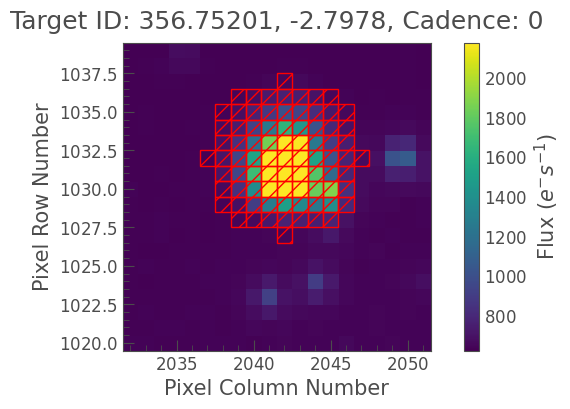

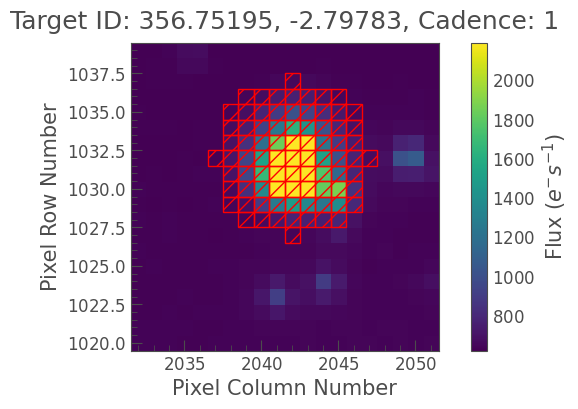

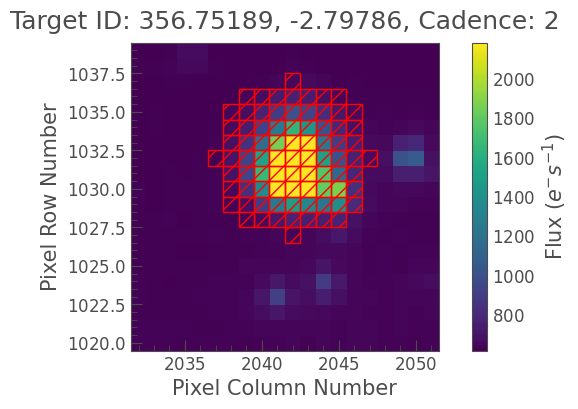

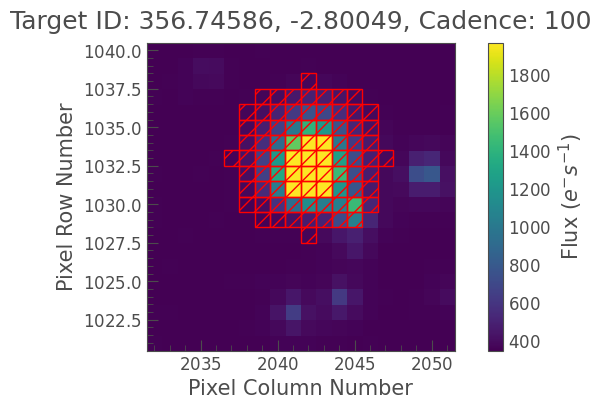

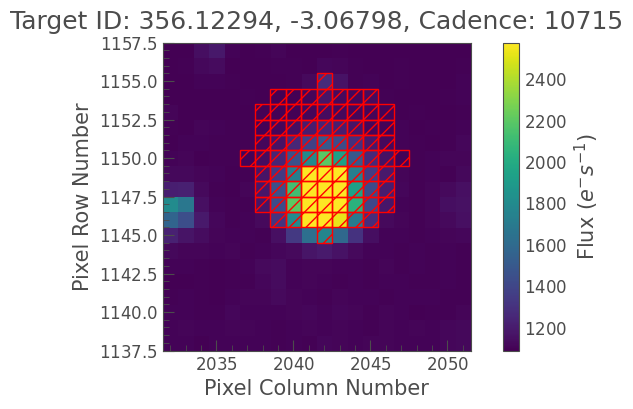

In [32]:
zoomed_aperture = circularAperture((20,20), (10, 12), 5)
tpf0.plot(aperture_mask = zoomed_aperture)
tpf1.plot(aperture_mask = zoomed_aperture, cadenceno = 1)
tpf2.plot(aperture_mask = zoomed_aperture, cadenceno = 2)
tpf100.plot(aperture_mask = zoomed_aperture, cadenceno = 100)
tpf10715.plot(aperture_mask = zoomed_aperture, cadenceno = 10715)


In [34]:
cadence = 0
pixel_y = 15
pixel_x = 10

flux_at_pixel = tpf1.flux[cadence, pixel_y, pixel_x]
flux1 = tpf1.flux[cadence]
max_flux_position = np.unravel_index(np.nanargmax(flux1), flux1.shape)


print(f"Maximum flux value: {flux1[max_flux_position]}")
print(f"Pixel with the most flux at cadence {cadence} is at position (y, x): {max_flux_position}")
print(f"Flux at pixel ({pixel_y}, {pixel_x}) for cadence {cadence}: {flux_at_pixel}")


Maximum flux value: 17119.443359375 electron / s
Pixel with the most flux at cadence 0 is at position (y, x): (11, 10)
Flux at pixel (15, 10) for cadence 0: 1005.2196044921875 electron / s


<Axes: title={'center': 'Target ID: 356.75201, -2.7978, Cadence: 0'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

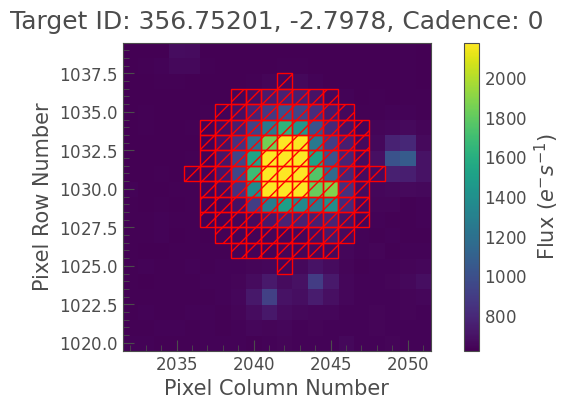

In [14]:
aperture = circularAperture((20,20), (10, 11), 6)
tpf1.plot(aperture_mask = aperture)


Flux-weighted centroid for cadence 10715 is at pixel (y, x): (10.99993634962008, 9.990269675794053)


<Axes: title={'center': 'Target ID: 356.12294, -3.06798, Cadence: 10715'}, xlabel='Pixel Column Number', ylabel='Pixel Row Number'>

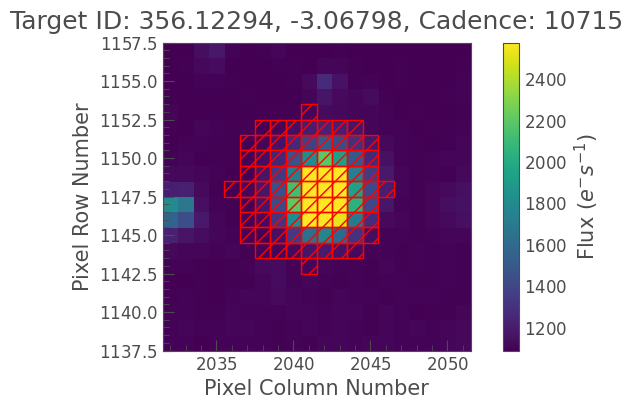

In [40]:
## idea: we take the naive circular aperture, then adjust based on a centroid mean
custom_aperture = zoomed_aperture
cadence = 10715
flux_at_cadence = tpf10715.flux[cadence]  # This gives you a 2D array: (y, x)

# Step 4: Apply the mask to get the fluxes within the aperture
masked_flux = flux_at_cadence[custom_aperture]

# Step 5: Get the pixel coordinates within the aperture
y_indices, x_indices = np.where(custom_aperture)

# Step 6: Calculate the weighted average of the pixel coordinates
total_flux = np.nansum(masked_flux)
if total_flux == 0:
    centroid_y, centroid_x = np.nan, np.nan
else:
    centroid_y = np.nansum(y_indices * masked_flux) / total_flux
    centroid_x = np.nansum(x_indices * masked_flux) / total_flux

print(f"Flux-weighted centroid for cadence {cadence} is at pixel (y, x): ({centroid_y}, {centroid_x})")

adapted_aperture = circularAperture((20,20), (int(centroid_x), int(centroid_y)), 5)
tpf10715.plot(aperture_mask = adapted_aperture, cadenceno = 10715)

In [42]:
cadence = 0
flux_within_aperture = np.nansum(tpf0.flux[cadence, adapted_aperture]) #relies on prev cell
print(f"Total flux in aperture for cadence {cadence} is {flux_within_aperture}")

Total flux in aperture for cadence 0 is 128423.234375 electron / s


In [20]:
#function dependencies: getData, circularAperture, 

def fluxPlot(df, sectorno, max_cadence):
    flux = []
    time = np.arange(0, max_cadence, 2000)
    cadence = 0

    for cadence in range(0, max_cadence, 2000):
        tpf = getData(df.loc[cadence, 'RA'], df.loc[cadence, 'DEC'], sectorno)
        naive_aperture = circularAperture((20,20), (10, 10), 6)   
    
        flux_at_cadence = tpf.flux[cadence]  # This gives you a 2D array: (y, x)
        # Step 4: Apply the mask to get the fluxes within the aperture
        masked_flux = flux_at_cadence[naive_aperture]

        # Step 5: Get the pixel coordinates within the aperture
        y_indices, x_indices = np.where(naive_aperture)

        # Step 6: Calculate the weighted average of the pixel coordinates
        total_flux = np.nansum(masked_flux)
        if total_flux == 0:
            centroid_y, centroid_x = np.nan, np.nan
        else:
            centroid_y = np.nansum(y_indices * masked_flux) / total_flux
            centroid_x = np.nansum(x_indices * masked_flux) / total_flux

        adapted_aperture = circularAperture((20,20), (int(centroid_x), int(centroid_y)), 5)
        flux_within_aperture = np.nansum(tpf.flux[cadence, adapted_aperture].value) 
        flux.append(flux_within_aperture)

    flux = np.array(flux)
    lc = lk.LightCurve(time = time, flux = flux)
    lc.plot()
    plt.show()

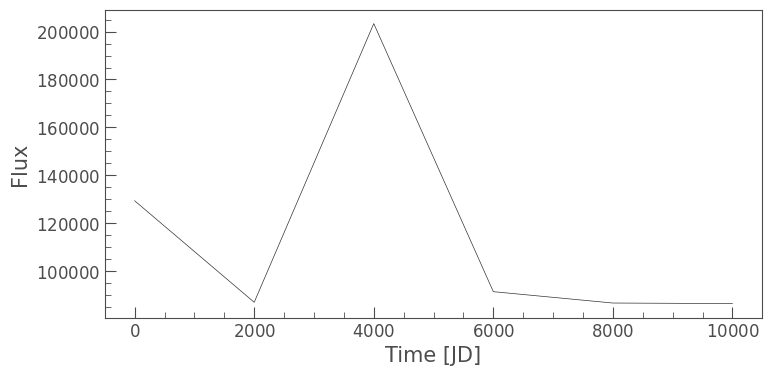

In [21]:
fluxPlot(df_70, 70, 10715)